In [14]:
# import sys, os
# sys.path.insert(0, "/Users/shah/CODE_BOOK_4/THESIS_WORKING/THESIS_2")
# sys.modules.pop("src", None)
# os.chdir("/Users/shah/CODE_BOOK_4/THESIS_WORKING/THESIS_2")

import sys, os
sys.path.insert(0, "/Users/shah/CODE_BOOK_4/THESIS_WORKING/THESIS_2")
sys.modules.pop("src", None)
os.chdir("/Users/shah/CODE_BOOK_4/THESIS_WORKING/THESIS_2")

In [17]:
YEAR = 2024

STRATEGY = '07_30'
MODEL_TYPE = 'mfiv200'

In [18]:
import pickle

if MODEL_TYPE == 'mfiv200':
    if STRATEGY == '07_30':
        if YEAR < 2022:
            with open(f"../msg_mfiv200/strategy_outputs/2019_22/07_30/backtest_results_{YEAR}.pkl","rb") as f:
                data = pickle.load(f)
        else :
            with open(f"../msg_mfiv200/strategy_outputs/2022_25/07_30/backtest_results_{YEAR}.pkl","rb") as f:
                data = pickle.load(f)
    elif STRATEGY == '01_03':
        if YEAR < 2022:
            with open(f"../msg_mfiv200/strategy_outputs/2019_22/01_03/backtest_results_{YEAR}.pkl","rb") as f:
                data = pickle.load(f)
        else :
            with open(f"../msg_mfiv200/strategy_outputs/2022_25/01_03/backtest_results_{YEAR}.pkl","rb") as f:
                data = pickle.load(f)
elif MODEL_TYPE == 'mfiv5':
    if STRATEGY == '07_30':
        if YEAR < 2022:
            with open(f"../strategy_outputs/2019_2022/07_30/backtest_results_{YEAR}.pkl","rb") as f:
                data = pickle.load(f)
        else :
            with open(f"../strategy_outputs/2022_2025/07_30/backtest_results_{YEAR}.pkl","rb") as f:
                data = pickle.load(f)
    elif STRATEGY == '01_03':
        if YEAR < 2022:
            with open(f"../strategy_outputs/2019_2022/01_03/backtest_results_{YEAR}.pkl","rb") as f:
                data = pickle.load(f)
        else :
            with open(f"../strategy_outputs/2022_2025/01_03/backtest_results_{YEAR}.pkl","rb") as f:
                data = pickle.load(f)


globals().update(data)

In [19]:
if MODEL_TYPE == 'mfiv5':
    if YEAR < 2022:
        outputs_by_year = pickle.load(open(r"../outputs_by_year/2019_2022/outputs_by_year_12mdls.pkl", "rb"))
    else:
        outputs_by_year = pickle.load(open(r"../outputs_by_year/2022_2025/outputs_by_year_12mdls.pkl", "rb"))

elif MODEL_TYPE == 'mfiv200':
    if YEAR < 2022:
        outputs_by_year = pickle.load(open(f"../msg_{MODEL_TYPE}/outputs_by_year/2019_22/outputs_by_year_12mdls.pkl", "rb"))
    else:
        outputs_by_year = pickle.load(open(f"../msg_{MODEL_TYPE}/outputs_by_year/2022_25/outputs_by_year_12mdls.pkl", "rb"))
        
    

In [20]:
models_to_test = [
    "ms_LSTM_wIV", "ms_LSTM_noIV", "ms_base", "garch",
    "xg_boost", "tarch", "midas", "sv", "gjr", "egarch",
    "ar10", "garch_m"
]


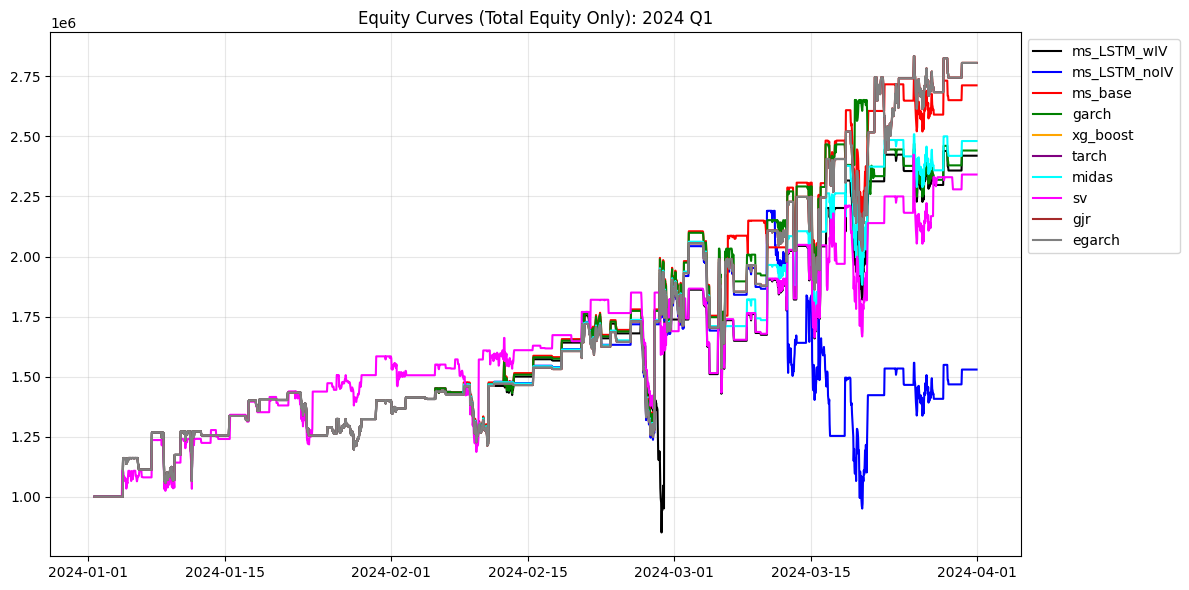

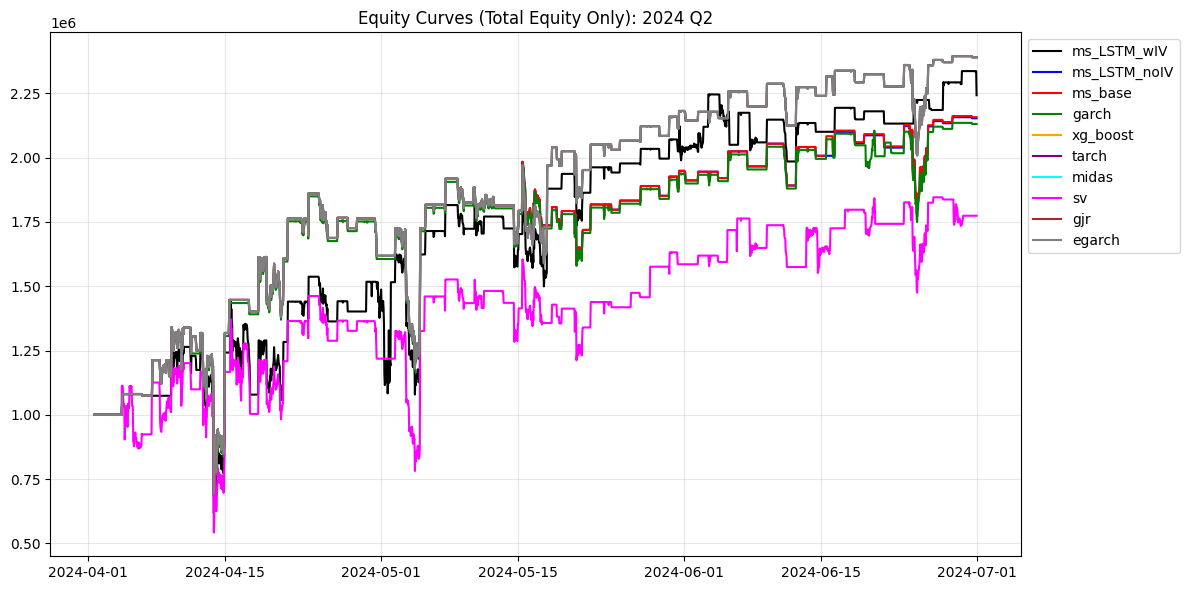

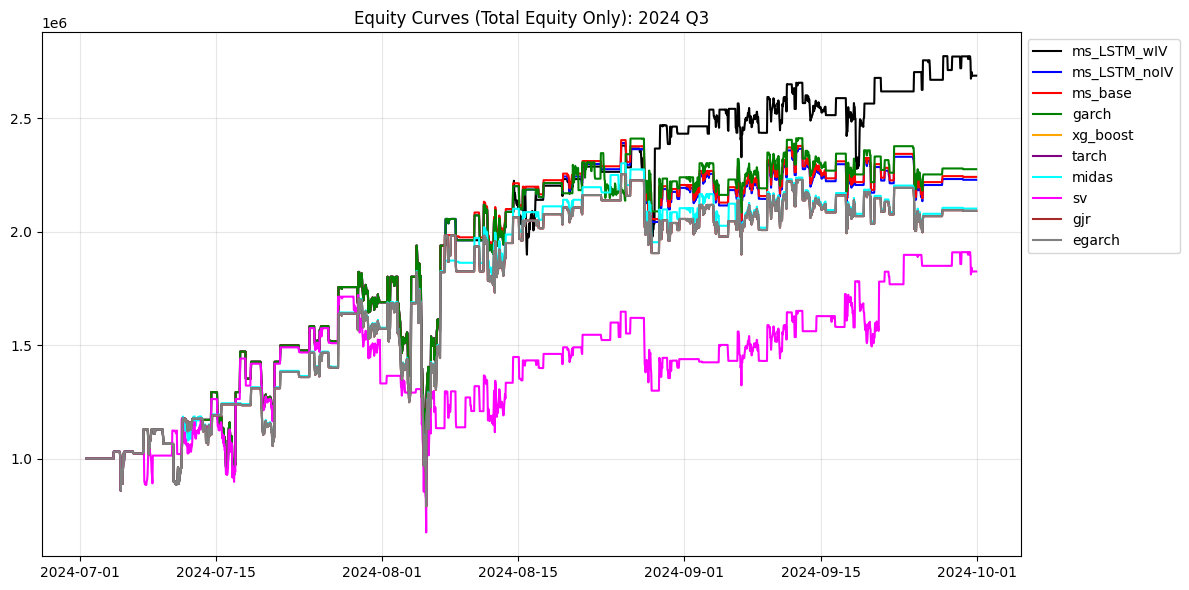

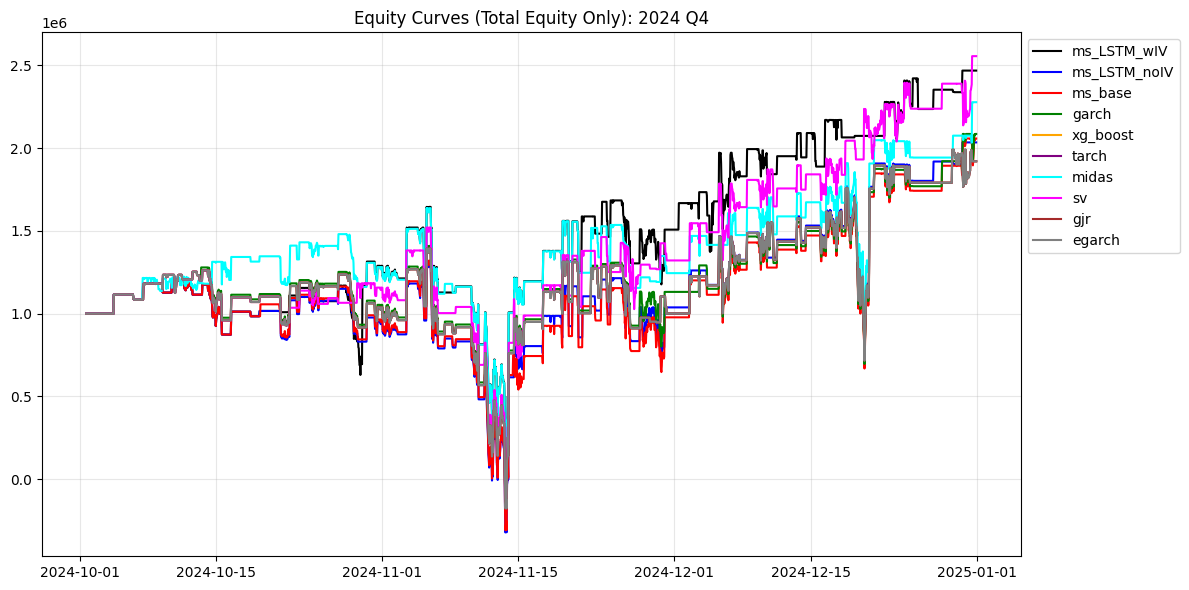

In [21]:
import matplotlib.pyplot as plt

# Define colors for consistency
colors = {
    "ms_LSTM_wIV": "black", "ms_LSTM_noIV": "blue", "ms_base": "red",
    "garch": "green", "xg_boost": "orange", "tarch": "purple",
    "midas": "cyan", "sv": "magenta", "gjr": "brown", "egarch": "gray"
}

for y in [YEAR]:
    for q in ["q1", "q2", "q3", "q4"]:
        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue
            
        plt.figure(figsize=(12, 6))
        plot_exists = False
        
        for model_name in models_to_test:
            var_name = f"{model_name}_{str(y)[2:]}_{q}"
            
            if var_name in globals():
                data = globals()[var_name]
                
                # Extract only the 'equity' column
                try:
                    # If it's a DataFrame
                    equity_curve = data['equity']
                except (TypeError, KeyError, IndexError):
                    # Fallback if it's a list/tuple of (equity, cash, options)
                    equity_curve = [x[0] for x in data] if isinstance(data[0], (list, tuple)) else data
                
                if len(equity_curve) > 0:
                    plt.plot(equity_curve, label=model_name, color=colors.get(model_name))
                    plot_exists = True
        
        if plot_exists:
            plt.title(f"Equity Curves (Total Equity Only): {y} {q.upper()}")
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

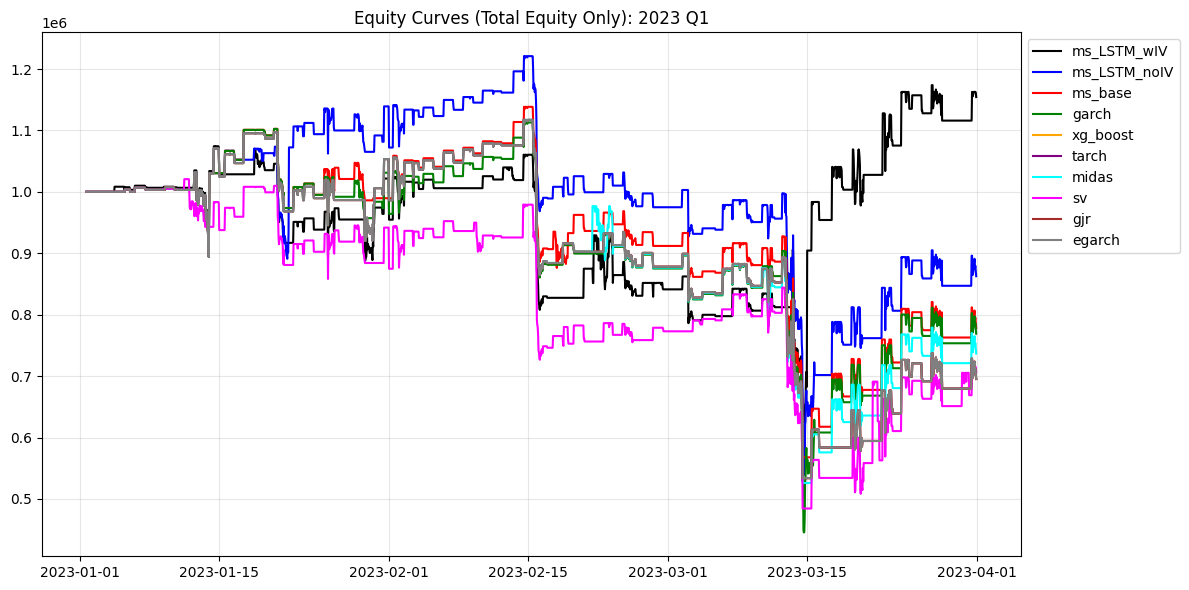

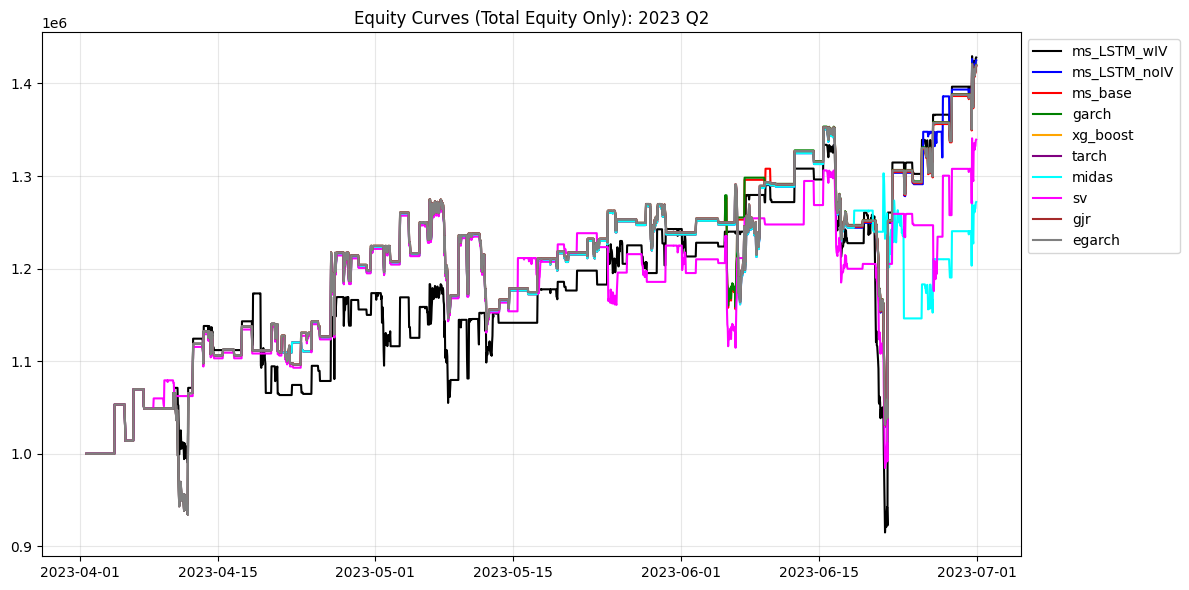

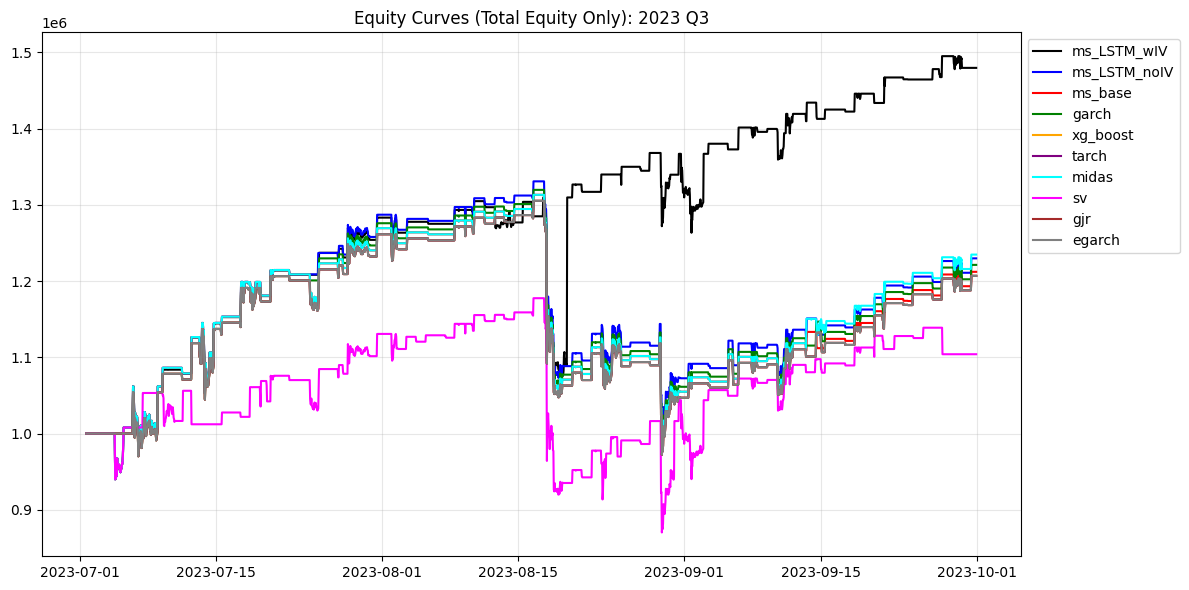

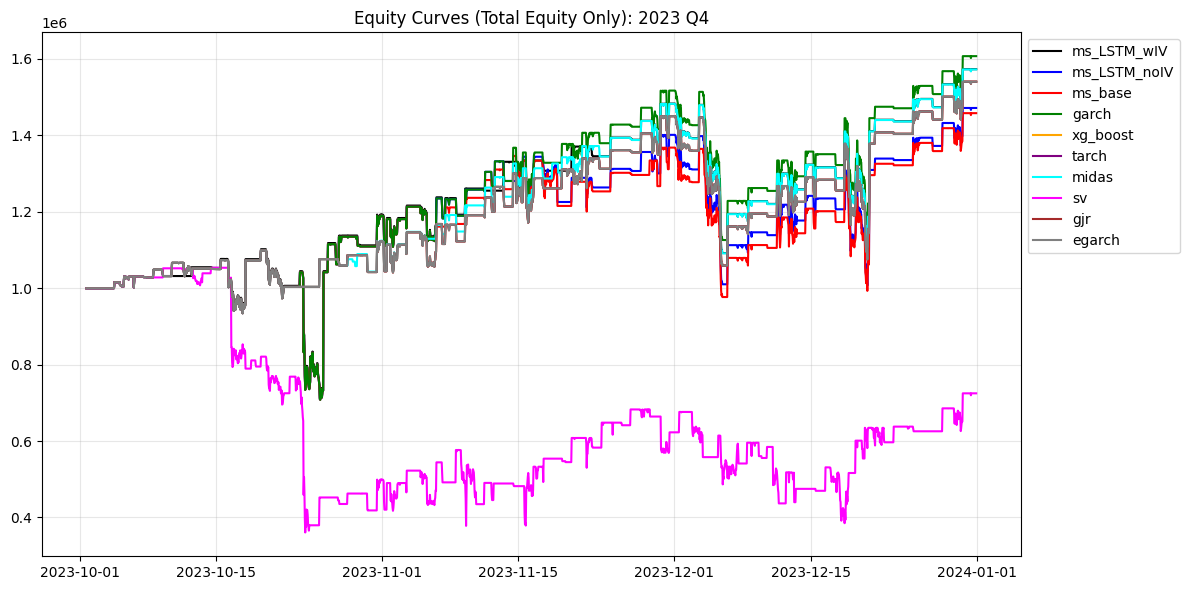

In [16]:
import matplotlib.pyplot as plt

# Define colors for consistency
colors = {
    "ms_LSTM_wIV": "black", "ms_LSTM_noIV": "blue", "ms_base": "red",
    "garch": "green", "xg_boost": "orange", "tarch": "purple",
    "midas": "cyan", "sv": "magenta", "gjr": "brown", "egarch": "gray"
}

for y in [YEAR]:
    for q in ["q1", "q2", "q3", "q4"]:
        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue
            
        plt.figure(figsize=(12, 6))
        plot_exists = False
        
        for model_name in models_to_test:
            var_name = f"{model_name}_{str(y)[2:]}_{q}"
            
            if var_name in globals():
                data = globals()[var_name]
                
                # Extract only the 'equity' column
                try:
                    # If it's a DataFrame
                    equity_curve = data['equity']
                except (TypeError, KeyError, IndexError):
                    # Fallback if it's a list/tuple of (equity, cash, options)
                    equity_curve = [x[0] for x in data] if isinstance(data[0], (list, tuple)) else data
                
                if len(equity_curve) > 0:
                    plt.plot(equity_curve, label=model_name, color=colors.get(model_name))
                    plot_exists = True
        
        if plot_exists:
            plt.title(f"Equity Curves (Total Equity Only): {y} {q.upper()}")
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

In [61]:
import pandas as pd

rows = []

for y in [YEAR]:
    for q in ["q1", "q2", "q3", "q4"]:
        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue

        for model_name in models_to_test:
            var_name = f"{model_name}_{str(y)[2:]}_{q}"

            if var_name in globals():
                data = globals()[var_name]

                try:
                    equity_curve = data["equity"]
                except (TypeError, KeyError, IndexError):
                    equity_curve = [x[0] for x in data] if isinstance(data[0], (list, tuple)) else data

                if len(equity_curve) > 0:
                    rows.append({
                        "Year": y,
                        "Quarter": q,
                        "Model": model_name,
                        "Start Equity": equity_curve.iloc[0] if hasattr(equity_curve, "iloc") else equity_curve[0],
                        "End Equity": equity_curve.iloc[-1] if hasattr(equity_curve, "iloc") else equity_curve[-1],
                    })

equity_summary = pd.DataFrame(rows)
equity_summary

,Year,Quarter,Model,Start Equity,End Equity
0,2022,q1,ms_LSTM_wIV,1000000.0,1.251186e+06
1,2022,q1,ms_LSTM_noIV,1000000.0,1.583753e+06
2,2022,q1,ms_base,1000000.0,1.312137e+06
3,2022,q1,garch,1000000.0,1.462579e+06
4,2022,q1,xg_boost,1000000.0,1.413107e+06
5,2022,q1,tarch,1000000.0,1.413107e+06
6,2022,q1,midas,1000000.0,1.581063e+06
7,2022,q1,sv,1000000.0,1.089554e+06
8,2022,q1,gjr,1000000.0,1.413107e+06
9,2022,q1,egarch,1000000.0,1.413107e+06


In [64]:
eq = equity_summary.copy()
eq["Return"] = eq["End Equity"] / eq["Start Equity"]

eq["Period"] = eq["Year"].astype(str) + "_" + eq["Quarter"]

cum_compare = (
    eq.sort_values(["Year", "Quarter"])
      .pivot_table(index="Period", columns="Model", values="Return")
      .cumprod()
      * 1_000_000
)


pd.options.display.float_format = "{:,.2f}".format
cum_compare

Model,ar10,egarch,garch,garch_m,gjr,midas,ms_LSTM_noIV,ms_LSTM_wIV,ms_base,sv,tarch,xg_boost
Period,,,,,,,,,,,,
2022_q1,"1,394,834.38","1,413,107.18","1,462,579.08","1,688,913.15","1,413,107.18","1,581,063.33","1,583,752.95","1,251,186.31","1,312,136.85","1,089,554.29","1,413,107.18","1,413,107.18"
2022_q2,"1,504,610.38","1,760,365.91","1,904,416.79","1,840,972.55","1,760,365.91","2,106,262.06","1,976,269.27","1,699,853.32","1,857,725.28","959,686.22","1,760,365.91","1,760,365.91"
2022_q3,"1,573,235.10","1,788,122.28","1,936,043.94","1,963,922.77","1,788,122.28","2,143,145.56","2,192,401.24","1,678,750.32","1,820,711.97","964,221.08","1,788,122.28","1,788,122.28"
2022_q4,"1,830,003.10","1,666,154.83","1,900,688.79","1,957,909.75","1,666,154.83","2,002,832.23","2,128,304.53","1,710,070.12","1,772,075.30","1,068,437.05","1,666,154.83","1,714,231.54"


In [ ]:

plt.savefig(f"equity_plots/equity_curves_{y}_{q}.png", dpi=300, bbox_inches="tight")
plt.close()